In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [5]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [8]:
df = pd.read_csv("Customer_Behaviour_Survey_responses.csv")

In [9]:
df.head()

,Timestamp,Age,Gender,Current State or Union Territory,City,Which Tier does your city belong to?,Marital Status,What is your financial status?,"Say for example , a similar product with similar features is being sold at half the price by an unknown seller as compared to a branded product. Would you purchase that product? or Simply Do you prefer cost over brands?",What is the Product Category that you shop very frequently?,How much time do you spend while picking the right product to buy?,"On a scale of 1 to 5 , how often do you shop in the selected product category monthly?",What is the average money that you spend while shopping the above items in one time?,Which product among Electronics do you shop very often?,Which product among Fashion do you shop very often?,Which product among Clothing do you shop very often?,Which OTT subscriptions do you use the most?,Which type of Books do you buy the most?
0,6/10/2021 22:41:22,21,Male,Uttar Pradesh,Lucknow,Tier 2,Not Married,Student,No,Electronics,Couple of Weeks,2,Between ₹1000-₹5000,"Utility Devices ( like pen drive , cables etc )",NaN,NaN,NaN,NaN
1,6/11/2021 16:08:43,21,Male,Uttar Pradesh,Lucknow,Tier 2,Not Married,Student,No,Electronics,Couple of Weeks,2,Between ₹1000-₹5000,"Utility Devices ( like pen drive , cables etc )",NaN,NaN,NaN,NaN
2,6/11/2021 16:12:18,19,Female,Uttar Pradesh,Kanpur,Tier 2,Not Married,Student,No,"Fashion ( Makeup, cosmetics, Perfume etc )",Within a day,4,Between ₹1000-₹5000,NaN,Jewellery,NaN,NaN,NaN
3,6/11/2021 16:14:29,25,Male,Maharashtra,Mumbai,Tier 1,Not Married,Regular Job,Yes,Clothing,An entire month,3,Greater than ₹5000,NaN,NaN,T-shirts / Shirts,NaN,NaN
4,6/11/2021 16:18:31,22,Female,Chandigarh,NaN,Tier 2,Not Married,Freelancing,No,"Fashion ( Makeup, cosmetics, Perfume etc )",Couple of Weeks,4,Between ₹1000-₹5000,NaN,Cosmetics,NaN,NaN,NaN


In [10]:
df.shape

(254, 18)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 18 columns):
 #   Column                                                                                                                                                                                                                       Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                       --------------  -----
 0   Timestamp                                                                                                                                                                                                                    254 non-null    str  
 1   Age                                                                                                                                                          

In [12]:
df.columns

Index(['Timestamp', 'Age ', 'Gender', 'Current State or Union Territory',
       'City', 'Which Tier does your city belong to?', 'Marital Status',
       'What is your financial status?',
       'Say for example , a similar product with similar features is being sold at half the price by an unknown seller as compared to a branded product. Would you purchase that product? or Simply Do you prefer cost over brands?',
       'What is the Product Category that you shop very frequently?',
       'How much time do you spend while picking the right product to buy?',
       'On a scale of 1 to 5 , how often do you shop in the selected product category monthly? ',
       'What is the average money that you spend while shopping the above items in one time?',
       'Which product among Electronics do you shop very often?',
       'Which product among Fashion do you shop very often?',
       'Which product among Clothing do you shop very often?',
       'Which OTT subscriptions do you use the most

In [13]:
df.isnull().sum()

Timestamp                                                                                                                                                                                                                        0
Age                                                                                                                                                                                                                              0
Gender                                                                                                                                                                                                                           0
Current State or Union Territory                                                                                                                                                                                                 0
City                                                                                        

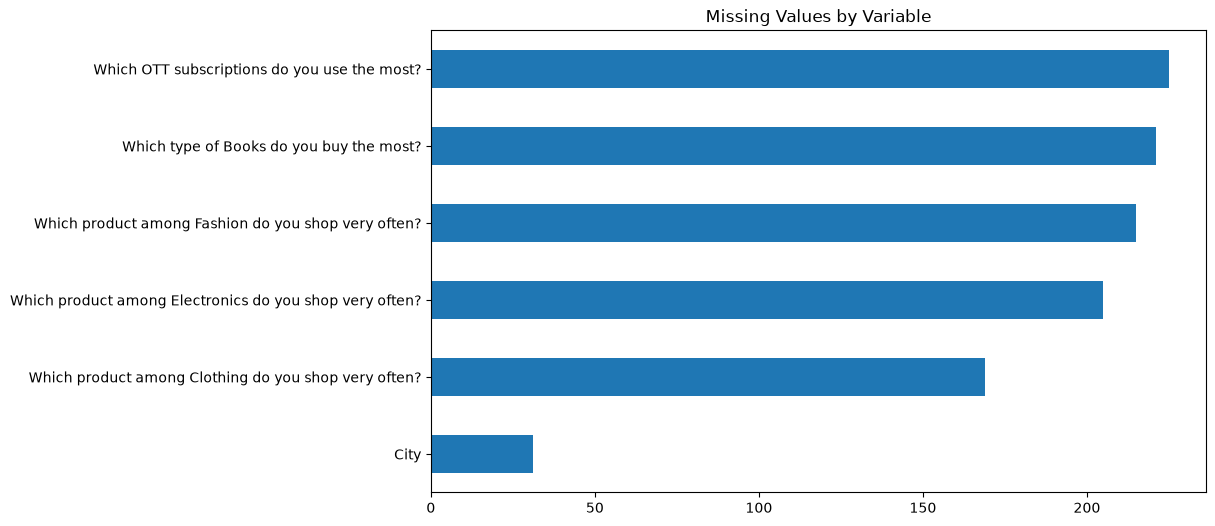

In [14]:
missing = df.isnull().sum()

missing[missing > 0].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Missing Values by Variable")
plt.show()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop_duplicates()

In [17]:
df.columns = df.columns.str.strip()

In [18]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [19]:
df['Age'].value_counts()

Age
24              19
19              18
22              16
20              16
54              14
21              11
25              10
52              10
27               9
55               9
23               9
18               7
17               7
51               7
26               6
33               6
30               6
48               6
28               6
29               5
31               5
53               5
16               4
15               4
45               4
35               4
50               4
37               3
56               3
43               2
32               2
58               2
41               2
62               2
49               2
39               2
40               1
55 years         1
34               1
Anurag Dubey     1
36               1
46               1
42               1
Name: count, dtype: int64

In [20]:
df['Age'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

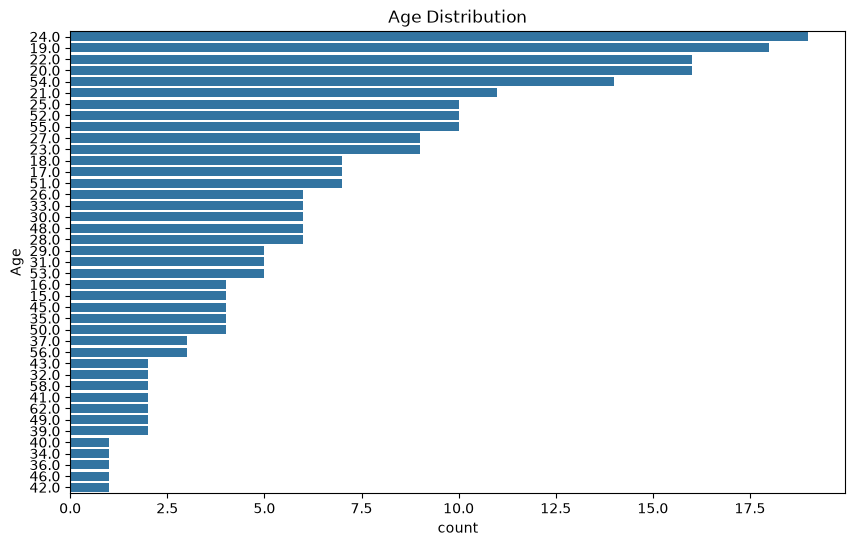

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Age',
    data=df,
    order=df['Age'].value_counts().index
)

plt.title("Age Distribution")
plt.show()

In [22]:
df['Gender'].value_counts()

Gender
Male      151
Female    103
Name: count, dtype: int64

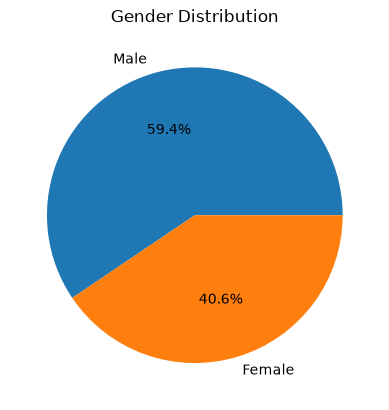

In [23]:
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title("Gender Distribution")
plt.show()

In [24]:
df['Which Tier does your city belong to?'].value_counts()

Which Tier does your city belong to?
Tier 2    122
Tier 1     90
Tier 3     42
Name: count, dtype: int64

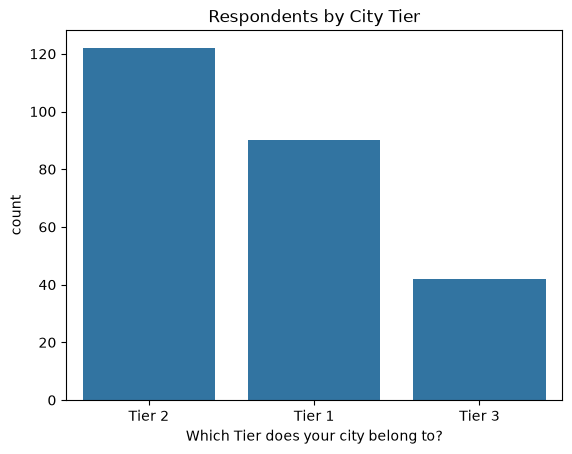

In [25]:
sns.countplot(
    x='Which Tier does your city belong to?',
    data=df
)

plt.title("Respondents by City Tier")
plt.show()

In [26]:
df['Marital Status'].value_counts()

Marital Status
Not Married    148
Married        106
Name: count, dtype: int64

In [27]:
df['What is your financial status?'].value_counts()

What is your financial status?
Regular Job    105
Student         93
Freelancing     35
Housewife       21
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='What is your financial status?'>

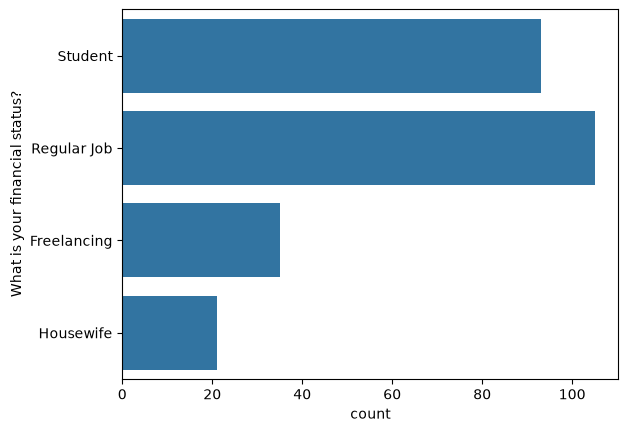

In [28]:
sns.countplot(
    y='What is your financial status?',
    data=df
)

In [29]:
brand_pref = df[
'Say for example , a similar product with similar features is being sold at half the price by an unknown seller as compared to a branded product. Would you purchase that product? or Simply Do you prefer cost over brands?'
]

brand_pref.value_counts()

Say for example , a similar product with similar features is being sold at half the price by an unknown seller as compared to a branded product. Would you purchase that product? or Simply Do you prefer cost over brands?
Yes      101
No        91
Maybe     62
Name: count, dtype: int64

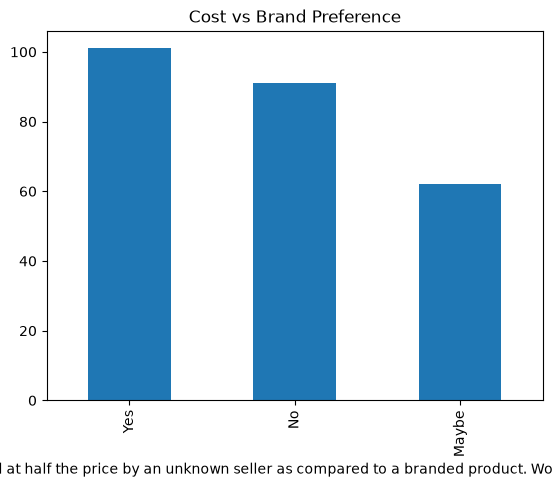

In [30]:
brand_pref.value_counts().plot(
    kind='bar'
)

plt.title("Cost vs Brand Preference")
plt.show()

In [31]:
category = df[
'What is the Product Category that you shop very frequently?'
]

category.value_counts()

What is the Product Category that you shop very frequently?
Clothing                                                    85
Electronics                                                 49
Fashion ( Makeup, cosmetics, Perfume etc )                  39
Books                                                       33
OTT Subscriptions ( Netflix , Amazon , prime video etc )    29
Food                                                         3
Food items                                                   2
House products                                               2
Home decor                                                   1
Kitchen utensils                                             1
Netflux                                                      1
Daily use items                                              1
Household goods                                              1
Grocery                                                      1
Daily needs                                               

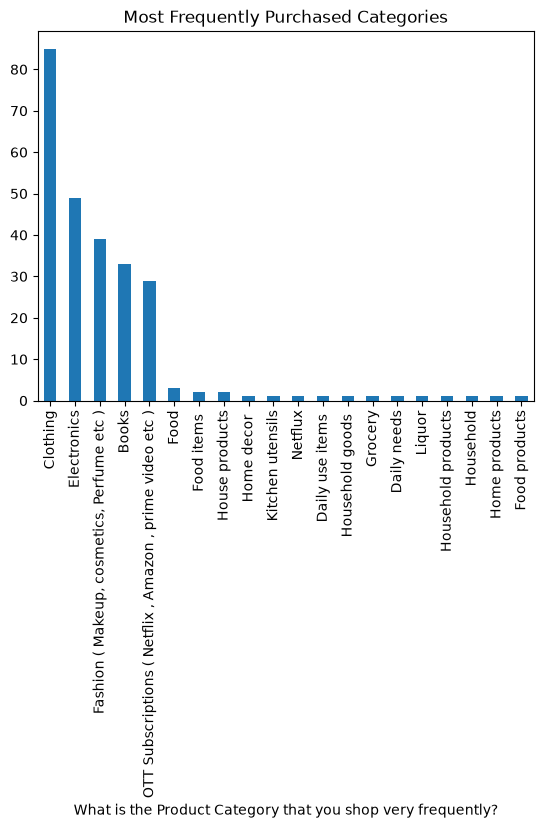

In [32]:
category.value_counts().plot(
    kind='bar'
)

plt.title("Most Frequently Purchased Categories")
plt.show()

In [33]:
freq_col = 'On a scale of 1 to 5 , how often do you shop in the selected product category monthly?'

In [34]:
df[freq_col].describe()

count    254.000000
mean       2.543307
std        1.370242
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        5.000000
Name: On a scale of 1 to 5 , how often do you shop in the selected product category monthly?, dtype: float64

In [35]:
mean_freq = df[freq_col].mean()

median_freq = df[freq_col].median()

std_freq = df[freq_col].std()

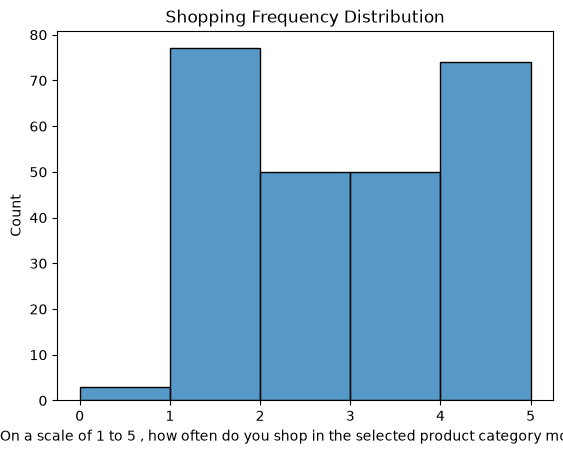

In [36]:
sns.histplot(
    df[freq_col],
    bins=5
)

plt.title("Shopping Frequency Distribution")
plt.show()

In [37]:
spend_col = 'What is the average money that you spend while shopping the above items in one time?'

In [38]:
df[spend_col].value_counts()

What is the average money that you spend while shopping the above items in one time?
Between ₹1000-₹5000    112
Less Than ₹1000         94
Greater than ₹5000      48
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='What is the average money that you spend while shopping the above items in one time?'>

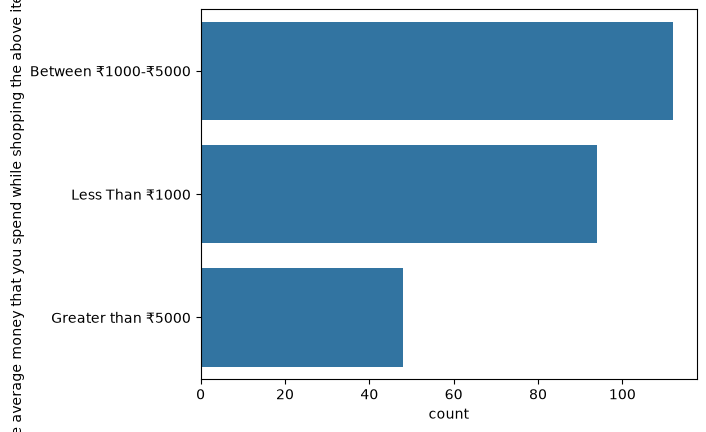

In [39]:
sns.countplot(
    y=spend_col,
    data=df,
    order=df[spend_col].value_counts().index
)

In [40]:
time_col = 'How much time do you spend while picking the right product to buy?'

In [41]:
df[time_col].value_counts()

How much time do you spend while picking the right product to buy?
Within a day                         113
Couple of Weeks                       68
Less than hour                        42
An entire month                       28
Depends on type of product             1
Sometimes I keep.in a wishlist nf      1
One week                               1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='How much time do you spend while picking the right product to buy?'>

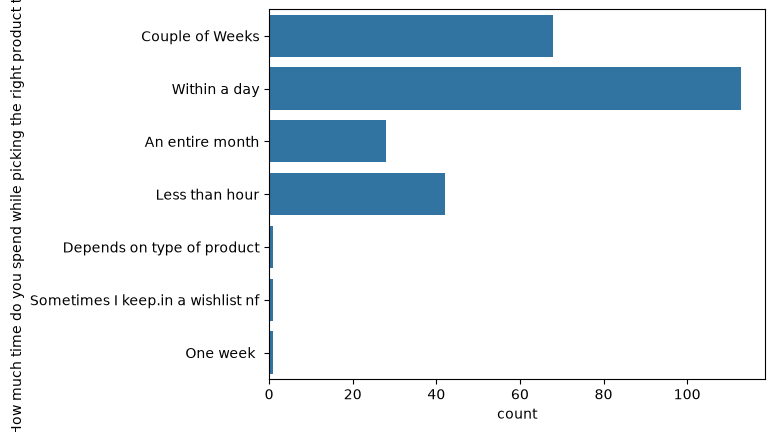

In [42]:
sns.countplot(
    y=time_col,
    data=df
)

In [43]:
pd.crosstab(
    df['Gender'],
    df['What is the Product Category that you shop very frequently?']
)

What is the Product Category that you shop very frequently?,Books,Clothing,Daily needs,Daily use items,Electronics,"Fashion ( Makeup, cosmetics, Perfume etc )",Food,Food items,Food products,Grocery,Home decor,Home products,House products,Household,Household goods,Household products,Kitchen utensils,Liquor,Netflux,"OTT Subscriptions ( Netflix , Amazon , prime video etc )"
Gender,,,,,,,,,,,,,,,,,,,,
Female,17,32,0,0,7,29,0,0,1,0,1,0,2,1,0,1,1,0,1,10
Male,16,53,1,1,42,10,3,2,0,1,0,1,0,0,1,0,0,1,0,19


<Axes: xlabel='What is the Product Category that you shop very frequently?', ylabel='Gender'>

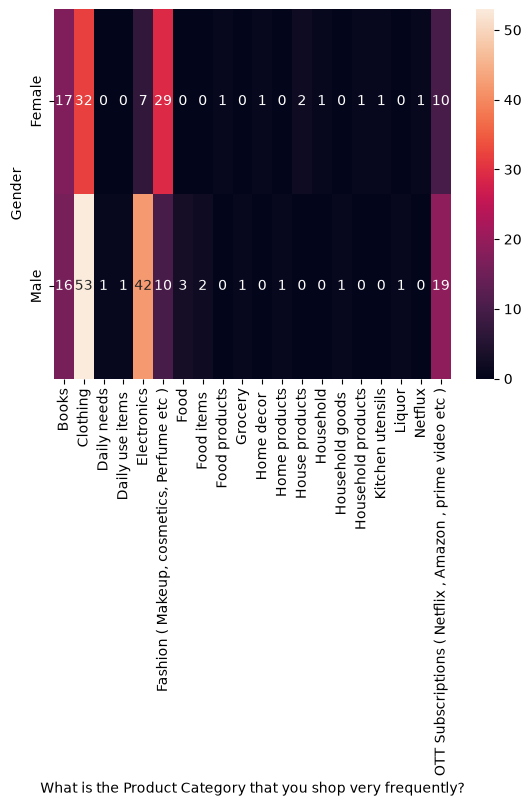

In [44]:
cross_tab = pd.crosstab(
    df['Gender'],
    df['What is the Product Category that you shop very frequently?']
)

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d'
)

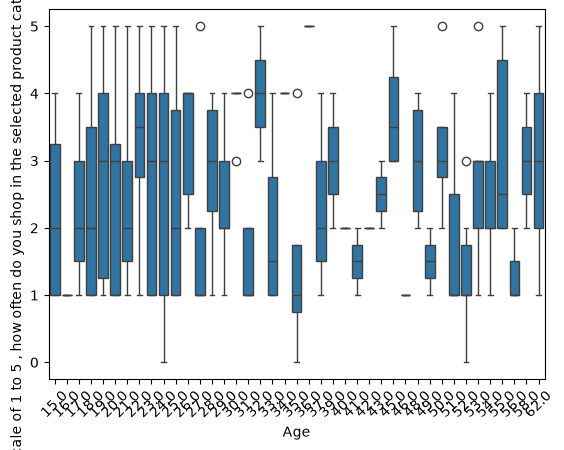

In [45]:
sns.boxplot(
    x='Age',
    y=freq_col,
    data=df
)

plt.xticks(rotation=45)
plt.show()

In [46]:
pd.crosstab(
    df['What is your financial status?'],
    df[spend_col]
)

What is the average money that you spend while shopping the above items in one time?,Between ₹1000-₹5000,Greater than ₹5000,Less Than ₹1000
What is your financial status?,,,
Freelancing,21,8,6
Housewife,5,4,12
Regular Job,52,27,26
Student,34,9,50
